# 7: Time-dependent Causal Inference

This chapter introduces causal inference for temporal data, drawing on statistics, machine learning, econometrics, and fields like finance, medicine, and social sciences.

We explore time-series and temporal data (e.g., biological networks), emphasising the need to address both time-dependence types for processes that cannot be split into discrete observations.


## 7.1: Time-series Data

A time series is a sequence of observations recorded in chronological order, where the sequence itself matters. 
Each observation at time $t$ is a data point, with time indices strictly increasing.

Time series data is often collected at regular intervals (e.g., hourly, daily) but can be irregular.
Values may depend on previous observations.
Data decomposes into trend (long-term direction) and seasonality (repeating patterns).

Time series data includes stock prices, temperatures, or website traffic: data points collected sequentially over time where order matters. 
How is causality defined in such data?

### 7.1.1: Causality in Time-Series

The long-standing debate on causality's relationship with time, particularly in time-series data, is addressed by Eichler (2013), who examines both philosophical and empirical aspects.

* **Temporal precedence** Cause precedes effect in time.
* **Physical influence**: Cause changes alter effects.
* **Probability raising**: A cause increases the chance of an effect occurring.

## 7.2: Granger Causality

Granger causality tests whether past values of one time series $X$ improve prediction of another $Y$ (Granger, 1969; Shojaie & Fox, 2021).

$$Var[Y_t − P(Y_t | H_{t-1})] \lt Var[Y_t − P(Y_t | H_{t-1} \ X_{t-1})]$$

$H_{\lt t}$ denotes all relevant variables up to time $t−1$. 
$H_{<t} \ X_{<t}$ is this history minus all prior $X$ values (Shojaie & Fox, 2021).

Granger causality indicates that including past values of $X$ improves predicting $Y$, but does not prove causation (Hoover 2001; Kleinberg 2012). 
It identifies *prima facie* causes needing further investigation (Eichler 2013) and serves as a causal discovery method (Gong et al. 2023).

The Granger test is typically performed using a vector autoregressive (VAR) model (Kilian 2006).

$$A^0 x_t = \sum_{k=1}^m A^k x_{t-k} + e_t$$

Each $\mathbf{A}^k$ (a $d \times d$ matrix) models feature relationships across lags $k=0, \ldots, m$, where lag $k$ indicates a $k$-unit time shift.
For example, the lag-3 term shows how data at $t-3$ affects $t$.
$\mathbf{e}_t$ is a $d$-dimensional error vector (Shojaie & Fox, 2021).

### 7.2.1: Assumptions required to use a VAR model

VAR models require specific data assumptions (Shojaie and Fox 2021).

* Time-series data must use continuous values only (real numbers), excluding categorical or discrete features. However, many real-world datasets contain such features.
* **Linear data**: Granger causality assumes linearity.
  Nonlinear relationships invalidate standard test results; nonlinear extensions exist but are not standard.
* Constant sampling rate must match causal timescale to avoid misleading Granger causality results.
* Granger causality tests assess whether past values of series $X$ predict future values of series $Y$, depending on the lag length used.
  Poor lag choice can cause inaccurate results.
* **Stationarity**: A stationary time series has time-invariant statistical properties.
  It may exhibit trends or cycles, but these must remain consistent over time.
* No measurement errors or omitted variables: This prevents endogeneity, where an unobserved confounder correlates with independent variables and affects the dependent variable.

If time-series assumptions fail, VAR cannot detect Granger causality (Shojaie & Fox, 2021).
If assumptions hold, Granger causality can be tested using VAR.

1. **Null hypothesis**: Past X values do not reduce prediction variance for Y.
2. Null hypothesis test: two models fitted*
   * Predicting future Y using past Y values.
   * Uses past Y and X values to forecast Y.
3. **Statistical Test**: An F-test compares two models.
   If the model using past X and Y values predicts Y better than one using only past Y values, X Granger-causes Y.

### 7.2.2: An example calculation

A synthetic bike-sharing dataset is generated for demonstration, using temperature as a feature and bike rentals as the target.
It contains 1,000 points (mean temperature 70°F, standard deviation 10°F), with a fixed random seed for reproducibility.

We performed a Granger causality test using [`statsmodels`](https://www.statsmodels.org/stable/).

In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of data points
n = 1000
temperature = np.random.normal(70, 10, n)
error = np.random.normal(0, 5, n)  # Some random error

# Assume that bike rentals depend on temperature with a lag
lagged_temperature = np.roll(temperature, shift=1)
lagged_temperature[0] = temperature[0]  # Handle the first value

bike_rentals = 10 + 0.5 * temperature + 0.3 * lagged_temperature + error

df = pd.DataFrame({
    'Temperature': temperature,
    'Bike_Rentals': bike_rentals
})
df

,Temperature,Bike_Rentals
0,74.967142,76.970490
1,68.617357,71.421989
2,76.476885,69.121802
3,85.230299,72.323531
4,67.658466,72.889439
...,...,...
995,67.188997,66.940390
996,87.976865,74.012525
997,76.408429,70.187901
998,64.288210,64.251299


Daily temperatures and bike rental counts. Plot the data.

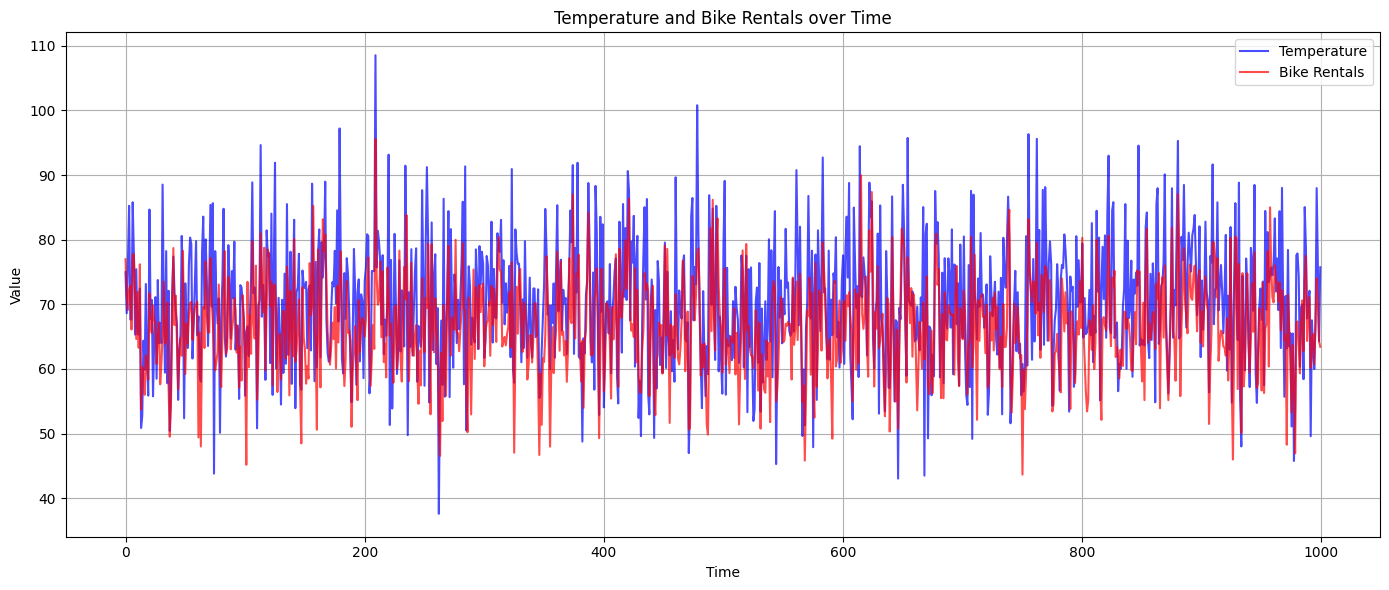

In [2]:
import matplotlib.pyplot as plt

# Plotting the dataset
plt.figure(figsize=(14, 6))

plt.plot(df['Temperature'], label='Temperature', color='blue', alpha=0.7)
plt.plot(df['Bike_Rentals'], label='Bike Rentals', color='red', alpha=0.7)
plt.title('Temperature and Bike Rentals over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.grid(True)
# plt.show()

<center>
  <a id="fig-granger"></a>
  <h6>Figure 7.1: Temperature (blue) and Bike Rentals (red) over Time</h6>
</center>

[Figure 7.1](#fig-granger) shows temperature (blue) and bike rentals (red) trending together over time, with minor noise from synthetic data.

For synthetic data, stationarity checks are unnecessary as the data meets all criteria.
Standard stationarity tests are the ADF and KPSS tests.

The Granger causality test requires a lagged time series format.

In [3]:

from statsmodels.tsa.stattools import grangercausalitytests

# Define data in the format for Granger test
data_for_test = df[['Bike_Rentals', 'Temperature']]

max_lag = 5
gc_test = grangercausalitytests(data_for_test, max_lag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=123.8638, p=0.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=124.2369, p=0.0000  , df=1
likelihood ratio test: chi2=117.0979, p=0.0000  , df=1
parameter F test:         F=123.8638, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=60.4864 , p=0.0000  , df_denom=993, df_num=2
ssr based chi2 test:   chi2=121.5820, p=0.0000  , df=2
likelihood ratio test: chi2=114.7275, p=0.0000  , df=2
parameter F test:         F=60.4864 , p=0.0000  , df_denom=993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=39.8454 , p=0.0000  , df_denom=990, df_num=3
ssr based chi2 test:   chi2=120.3814, p=0.0000  , df=3
likelihood ratio test: chi2=113.6504, p=0.0000  , df=3
parameter F test:         F=39.8454 , p=0.0000  , df_denom=990, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=29.5971 , p=0.0000  

/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


For lags 1–5, p-values are near zero, indicating strong evidence that temperature Granger-causes bike rentals. This aligns with the synthetic data, which generated rentals based on current and lag-1 temperature.

### 7.2.3: Violating an assumption

We create a bike rental dataset violating the no endogeneity assumption by introducing a confounding weather variable, `WeatherEffect`, omitted from the Granger test to demonstrate the assumption's importance.

In [4]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

n = 1000
temperature = np.random.normal(70, 10, n)
error = np.random.normal(0, 5, n)

# Generate WeatherEffect variable
weather_effect = np.random.normal(0, 5, n)

# Modify Temperature and Bike Rentals generation to account for WeatherEffect
temperature_with_effect = temperature + 0.2 * weather_effect
bike_rentals_with_effect = 10 + 0.5 * temperature_with_effect + \
                           0.3 * np.roll(temperature_with_effect, shift=1) + \
                           error + 0.5 * weather_effect

# Create dataframe without WeatherEffect for Granger test
df_effect = pd.DataFrame({
    'Temperature': temperature_with_effect,
    'Bike_Rentals': bike_rentals_with_effect
})

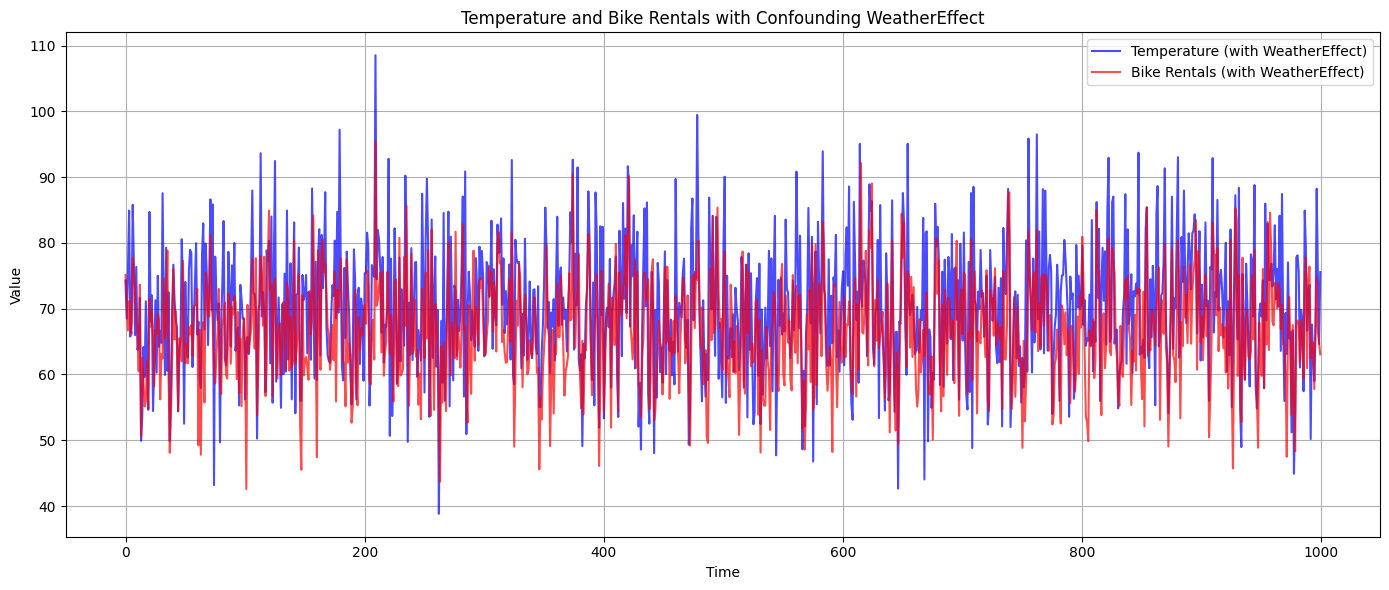

In [5]:
import matplotlib.pyplot as plt

# Plotting the confounded dataset
plt.figure(figsize=(14, 6))

plt.plot(df_effect['Temperature'], label='Temperature (with WeatherEffect)',
         color='blue', alpha=0.7)
plt.plot(df_effect['Bike_Rentals'], label='Bike Rentals (with WeatherEffect)',
         color='red', alpha=0.7)
plt.title('Temperature and Bike Rentals with Confounding WeatherEffect')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.grid(True)
# plt.show()

<center>
  <a id="fig-granger-confounded"></a>
  <h6>Figure 7.2: Temperature (blue) and Bike Rentals (red) over Time</h6>
</center>

[Figure 7.2](#fig-granger-confounded) shows temperature (blue) and bike rentals (red), both influenced by `WeatherEffect`, over time.

The `WeatherEffect` isn't shown directly, but its influence causes temperature and bike rentals to move together.
This shows how omitting a key variable creates false relationships.

We apply the Granger causality test to confounded data.

In [6]:

from statsmodels.tsa.stattools import grangercausalitytests

# Define data in the format for Granger test
data_for_test = df_effect[['Bike_Rentals', 'Temperature']]

max_lag = 5
gc_test = grangercausalitytests(data_for_test, max_lag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=109.4733, p=0.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=109.8031, p=0.0000  , df=1
likelihood ratio test: chi2=104.1773, p=0.0000  , df=1
parameter F test:         F=109.4733, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=53.9824 , p=0.0000  , df_denom=993, df_num=2
ssr based chi2 test:   chi2=108.5085, p=0.0000  , df=2
likelihood ratio test: chi2=103.0052, p=0.0000  , df=2
parameter F test:         F=53.9824 , p=0.0000  , df_denom=993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=35.7174 , p=0.0000  , df_denom=990, df_num=3
ssr based chi2 test:   chi2=107.9097, p=0.0000  , df=3
likelihood ratio test: chi2=102.4598, p=0.0000  , df=3
parameter F test:         F=35.7174 , p=0.0000  , df_denom=990, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=26.6052 , p=0.0000  

/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Notice that the Granger test output matches Section 7.2.2's unconfounded result.

Near-zero p-values (lags 1–5) suggest temperature Granger-causes bike rentals.
However, endogeneity from the omitted `WeatherEffect` variable makes results unreliable.
Granger tests cannot detect such assumption violations.

### 7.2.4: Extensions to Granger causality

To overcome limitations in Section 7.2.1, various Granger causality extensions exist.
See Shojaie and Fox (2021) for details; this section lists only some incompletely.

* **Network Granger causality** identifies causal links in multivariate systems (e.g., gene networks) by showing Granger causes as nonzero entries in lag matrices and instantaneous effects as nonzero entries in the inverse error covariance matrix (Shojaie & Fox, 2021).
* **Lag selection VAR models**: Select optimal lag from data, avoiding the need for a pre-specified lag order (Nicholson et al., 2015).
* **Non-stationary VAR models** bypass Granger causality's stationarity assumption (Bai et al., 2020).
* **Discrete time-series:** categorical data applications (Weiß, 2018)
* **Mismatched sampling rates**: causal relationships not aligning with sampling timescales (Zhou et al., 2013)
* **Nonlinear time-series methods** extend beyond linear relationships (Amblard & Michel, 2010).

## 7.3: Logic-based Methods

This section introduces logic-based methods for time series analysis.
These methods, first proposed by Kleinberg and Mishra (2009), represent causal relationships using probabilistic temporal logic.
They combine causal discovery and inference (Gong et al., 2023).
The following text explains key concepts before detailing an advancement by Zheng and Kleinberg (2017).

### 7.3.1: Probabilistic Computation Tree Logic (PCTL)

Current methods ignore the time window between cause and effect, making them unsuitable for time-series analysis where timing affects outcomes. This chapter introduces methods accounting for temporal relationships and automated reasoning using probabilistic temporal logic.

#### 7.3.1.1: Temporal Logic

Temporal logic formalises reasoning about time-based propositions using operators to represent temporal relationships.
It analyses event timing and sequence but cannot model probabilistic relationships.

Probabilistic temporal logic (PTL) captures temporal and probabilistic event relationships under uncertainty.

#### 7.3.1.2" Probabilistic temporal logic

**Probabilistic temporal logic (PTL)** extends temporal logic by assigning probabilities to propositions, enabling nuanced reasoning about event sequences (e.g., "A usually precedes B").
However, PTL alone cannot model system evolution, as probabilistic systems have multiple possible futures.

PCTL extends CTL with probabilistic reasoning to analyse time-evolving probabilistic systems.
It specifies properties like state reachability probabilities, expected time to states, and temporal constraints, enabling assessment of possible future behaviours within defined time frames.

#### 7.3.1.3: Probabilistic Kripke Structures

Probabilistic Computation Tree Logic models system transitions using a probabilistic Kripke structure (PKS), a directed graph where nodes represent states and edges represent probabilistic transitions labelled with enabling conditions.

PKS models probabilistic systems to verify temporal properties.
For example, "eventually property P holds with at least 90% probability" is true if a path exists to a state where P holds with ≥90% probability.
PKS is used in formal verification to confirm systems meet specifications.

##### 7.3.1.3.1: Describing the System

PCTL describes systems using atomic propositions and probabilistic Kripke structures, expressing variable properties with probability and temporal aspects.

Atomic propositions are denoted by $A$.
The PKS is a four-tuple $K = (S, s_i, L, T)$ (Kleinberg, 2012).

* $S$ is a finite set of states
* $s_i$ is the initial state
* $L: S \rightarrow 2^A$ is a labelling function assigning to each state the atomic propositions that hold.
* $T: S \times S \to [0,1]$ is a probabilistic transition function that satisfies $\sum_{s' \in S} T(s,s') = 1$ for all $s \in S$.

$K$ determines possible transitions and their probabilities; $L(s)$ is state $s$'s label.
In practice, $K$ is not defined or inferred.

PCTL was extended to handle mixed discrete and continuous data in a single dataset (Kleinberg 2011).

##### 7.3.1.3.2$ Example: The Monty Hall Problem

This example uses the Monty Hall problem—a probability puzzle from the game show *Let's Make a Deal* (hosted by Monty Hall) to illustrate a probabilistic Kripke structure.
It became widely known after Marilyn vos Savant's 1990 column.

The problem is as follows:

1. Three doors: 1, 2, 3.
2. One door hides a car; the other two hide goats.
3. The player selects a door (e.g., Door 1).
4. Monty Hall opens another door to reveal a goat.
5. The host asks if the player wants to switch to the remaining unopened door or stick with their original choice.

The Monty Hall problem asks whether to stick with or switch doors.
We omit the solution, instead modelling it as a probabilistic Kripke structure.

**Monty Hall System States**

First, define atomic propositions representing the problem.

| Proposition        | Description              |
|--------------------|--------------------------|
| CarBehindDoor1     | Car behind door 1        |
| CarBehindDoor2     | Car behind door 2        |
| CarBehindDoor3     | Car behind door 3        |
| PlayerChoosesDoor1 | Player picks door 1      |
| PlayerChoosesDoor2 | Player picks door 2      |
| PlayerChoosesDoor3 | Player picks door 3      |
| PlayerSwitches     | Player switches          |
| HostOpensDoor1     | Host opens door 1 (goat) |
| HostOpensDoor2     | Host opens door 2 (goat) |
| HostOpensDoor3     | Host opens door 3 (goat) |
| PlayerWins         | Player wins              |
| PlayerLoses        | Player loses             |

The player's state is defined by what they know about the door locations at the game's start.

The Monty Hall problem's simple sequence is shown in a table.
Columns represent time steps; 1s indicate true states.
The first 1 in a row shows when a state changes.

**Game 1**

Car behind 1. Player chooses 2. Host opens 3. Player switches to 1 and wins.

| Proposition        | $t_1$ | $t_2$ | $t_3$ | $t_4$ | $t_5$ |
|--------------------|:-----:|:-----:|:-----:|:-----:|:-----:|
| CarBehindDoor1     |   1   |   1   |   1   |   1   |   1   |
| CarBehindDoor2     |   0   |   0   |   0   |   0   |   0   |
| CarBehindDoor3     |   0   |   0   |   0   |   0   |   0   |
| PlayerChoosesDoor1 |   0   |   0   |   0   |   1   |   1   |
| PlayerChoosesDoor2 |   0   |   1   |   1   |   0   |   0   |
| PlayerChoosesDoor3 |   0   |   0   |   0   |   0   |   0   |
| PlayerSwitches     |   0   |   0   |   0   |   1   |   0   |
| HostOpensDoor1     |   0   |   0   |   0   |   0   |   0   |
| HostOpensDoor2     |   0   |   0   |   0   |   0   |   0   |
| HostOpensDoor3     |   0   |   0   |   1   |   0   |   0   |
| PlayerWins         |   0   |   0   |   0   |   0   |   1   |
| PlayerLoses        |   0   |   0   |   0   |   0   |   0   |

**Game 2**

Car behind door 2. Player picks door 2, host opens door 1, switches and loses.

| Proposition        | $t_1$ | $t_2$ | $t_3$ | $t_4$ | $t_5$ |
|--------------------|:-----:|:-----:|:-----:|:-----:|:-----:|
| CarBehindDoor1     |   0   |   0   |   0   |   0   |   0   |
| CarBehindDoor2     |   1   |   1   |   1   |   1   |   1   |
| CarBehindDoor3     |   0   |   0   |   0   |   0   |   0   |
| PlayerChoosesDoor1 |   0   |   0   |   0   |   0   |   0   |
| PlayerChoosesDoor2 |   0   |   1   |   1   |   0   |   0   |
| PlayerChoosesDoor3 |   0   |   0   |   0   |   1   |   1   |
| PlayerSwitches     |   0   |   0   |   0   |   1   |   0   |
| HostOpensDoor1     |   0   |   0   |   1   |   0   |   0   |
| HostOpensDoor2     |   0   |   0   |   0   |   0   |   0   |
| HostOpensDoor3     |   0   |   0   |   0   |   0   |   0   |
| PlayerWins         |   0   |   0   |   0   |   0   |   0   |
| PlayerLoses        |   0   |   0   |   0   |   0   |   1   |

**Game 3**

Car behind 2. Player chooses 3, host reveals 1, switches, wins.

| Proposition        | $t_1$ | $t_2$ | $t_3$ | $t_4$ | $t_5$ |
|--------------------|:-----:|:-----:|:-----:|:-----:|:-----:|
| CarBehindDoor1     |   0   |   0   |   0   |   0   |   0   |
| CarBehindDoor2     |   1   |   1   |   1   |   1   |   1   |
| CarBehindDoor3     |   0   |   0   |   0   |   0   |   0   |
| PlayerChoosesDoor1 |   0   |   0   |   0   |   1   |   1   |
| PlayerChoosesDoor2 |   0   |   0   |   0   |   0   |   0   |
| PlayerChoosesDoor3 |   0   |   1   |   1   |   0   |   0   |
| PlayerSwitches     |   0   |   0   |   0   |   1   |   0   |
| HostOpensDoor1     |   0   |   0   |   1   |   0   |   0   |
| HostOpensDoor2     |   0   |   0   |   0   |   0   |   0   |
| HostOpensDoor3     |   0   |   0   |   0   |   0   |   0   |
| PlayerWins         |   0   |   0   |   0   |   0   |   0   |
| PlayerLoses        |   0   |   0   |   0   |   0   |   1   |

Initially, all doors are closed. 
The player selects one door. 
The host then opens another door revealing a goat, eliminating one incorrect choice. 
The player may switch to the remaining unopened door or stick with their initial choice. 
The outcome is either a win (car selected) or loss (goat selected), with the car's position unknown at the start.


###### 7.3.1.3.2.1: Properties of State and Path Formulas

Computation Tree Logic (CTL) uses state formulas (for properties of a single state) and path formulas (for properties across sequences of states).
For example, requiring an atomic proposition to hold in a state is a state formula.

Summarise properties of state and path formulas.

1. Each proposition in (A) is a state formula
2. If $f$ and $g$ are state formulas, then so are $\neg f$, $f \lor g$, $f \land g$ and $f \to g$.
3. If $f$ and $g$ are state formulas and $t$ is a non-negative integer or $\infty$, then $(f, U^{\leq t} g)$ and $(f, W^{\leq t} g)$ are path formulas.
4. If $f$ is a path formula and $0 \leq p \leq 1$, then $[f]_{\geq p}$ and $[f]_{> p}$ are state formulas.

The last three properties require explanation.

**Property (2)** permits combining state formulas using propositional logic (or, and, not), enabling automatic state labelling (Kleinberg, 2012).

**Property (3):** In PCTL, $U$ denotes *until*: formula $f$ must hold throughout a path until $g$ becomes true, within $t$ steps.
$W$ denotes *weak until*: $f$ must hold for at least $t$ steps unless $g4 becomes true within $t$ steps.

**Property (4)** enables constructing state formulas using *until* $U^{\leq t}$ or *unless* with probability bounds.
For example, $[f, U^{\leq t}_{\geq p}, g]$ means $g$ becomes true within $t$ steps with probability $≥ p$, while $f$ remains true throughout the path.
This state formula's probability is the sum of path probabilities (product of transition probabilities along each path).

The temporal operator $\leadsto$ ("leads to") is defined as:
$f_1 \leadsto_{\ge p}^{\le t} f_2 \equiv AG[f_1 \rightarrow F_{\ge p}^{\le t} f_2]$ means $f_1$ leads to $f_2$ within $t$ steps, with probability $p$, on all paths.

To express that $a$ occurs before $b$ (any time prior), replace the time interval $|t_1 - t_2|$ with $\infty$ (Kleinberg & Mishra, 2010).

### 7.3.2: Logical Conditions for Causality

PCTL describes probabilistic event relationships over time using temporal logic.
It frames verification as model checking (Clarke & Schlingloff 1996), though this chapter avoids model checking since real-world data: rather than a predefined model—provides states, labels, and transition probabilities.
Instead, we identify potential causes and verify which are likely true causes.


#### 7.3.2.1: Identifying Potential Causes

This section explains *prima facie* causes—Latin for "at first sight"—meaning potential causes that appear valid based on initial evidence, as used in legal contexts.

1. $F^{\le \infty}_{\gt 0} c$
2. $c \leadsto^{\ge 1,\le \infty}_{\ge p} e$
3. $F^{\le \infty}_{\lt p} e$

**Condition (1)** requires at least one state where $c$ eventually holds with positive probability.
**Condition (2)** states that $c$ being true leads to $e$ in the future with positive probability.
**Condition (3)** specifies the overall probability of reaching $e$ is less than $p$.
Together, these imply $c$ must occur at least once, and the conditional probability of $e$ given $c$ exceeds the marginal probability of $e$.

#### 7.3.2.2: Causal significance

In Section 2.5, we discussed the average treatment effect.
Kleinberg and Mishra (2010) introduced average causal significance (ACS, $\epsilon_{avg}$), which quantifies the causal significance of a cause $c$ to an effect $e$ where $c$ leads to $e$ within time window $[r, s]$ with probability $p$ (denoted $c \leadsto^{\ge r,\le s}_{\ge p} e$ ).

$$\epsilon_{avg}(c_{r-s}, e) = \frac{\sum_{x \in X \setminus c} P(e \mid c, x) - P(e \mid \neg c, x)}{|X \setminus c|} $$

The ACS numerator is the difference in effect probability when cause $c$ (from set $X$) is included versus excluded.
It mirrors the average treatment effect, comparing $P(e | X with c)$ to $P(e | X without c)$.

### 7.3.3: Identifying Token Causes

#### 7.3.3.1: Types of Causes

Two causal relationship types exist: **token-level** (specific events) and **type-level** (general patterns across events).
This section focuses on type-level relationships.

#### 7.3.3.2: Defining Token-level Causal Significance

Zheng and Kleinberg (2017) demonstrate that the ACS computes the significance of a token-level cause.
Specifically, the significance of cause instance $c_{t'}$ (type $c$) at time $t'$ for effect $e$ at time $t$ is defined as:

$$S(c_{t'}, e_t) = \epsilon_\text{avg}(c_{r-s}, e) \times P(c_{t'} | \mathcal{V}) /times f(c_{t'}, e_t, r, s)$$

Where $\mathcal{V}$ is the time series sequence, $\epsilon_\text{avg}$ is the average causal significance of a type-level cause $c$ on effect $e$, $P(c \mid \mathcal{V})$ is the probability of cause $c$ given the sequence, and $\mathcal{f}$ is a weighting function measuring how well the time gap between $c$ and $e$ fits the type-level window $[r, s]$.

1. When $t \in [t' + r, t' + s]$, $\mathcal{f}(c_{t'}, e_t) = 1$,
2. $\mathcal{f}$ decreases monotonically outside the specified range,
3. $\mathcal{f}(c_{t^{\prime}} , e_t) \in [0, 1]$.

#### 7.3.3.3: Computing Significance of Token Causes

Zheng & Kleinberg (2017) provide algorithms to compute token cause significance and identify token-level causes, assuming these are observed in data.
The method focuses solely on single-variable causes.

##### 7.3.3.3.1: Computing(\mathcal{f})from data

Describes Zheng and Kleinberg's 2017 algorithm for estimating $f$ from time-series data.

**Algorithm 1:** $\text{compute}(f(V, T, H, l_max, D))$

**Input:**

* $V$, a set of variables,
* $T$, length of the time series,
* $H$: all causal relationships $v \in V$,
* $l_\text{max}$, the maximum time lag to test,
* $D$, a $V \times T£ matrix, holds variable values over time.

**Output:**

* $F$: a list of functions $\mathcal{f}$ for each relationship in $H$.

**Procedure:**

1. For each $h \in H$ with $c \leadsto^{\ge r, \le s}_{\ge p} e$, do
    1. Calculate $\epsilon_\text{avg}$ for lags $1$ to $\text{lmax}$ using $D$.
    2. Normalize $\epsilon_\text{avg}$ by maximum.
    3. Delete outliers where $\epsilon_\text{avg} \lt 0$
    4. $\mathcal{f}(c_{t'}, e_t, r, s) = 1$ when $t - t' \in [r, s]$.
    5. $f(c_{t'}, e_t, r, s)$ is fitted to $\epsilon_\text{abg}$ via nonlinear least squares for $(t - t') \in [1, r) \cup (s, \text{lmax}]$. Add $f$ to $F$.
2. return $F$

Two explanatory notes:

* A time lag is the difference between cause and effect.
  For each causal relationship, a time window $[r, s]$ defines acceptable lags; any difference within this window counts as a valid lag.
* Matrix $D$ represents the time series, with each row corresponding to a variable in $\mathcal{V}$ and each column to a time step.

Algorithm 1 provides $\mathcal{f}$ and $\epsilon_\text{avg}$ for computing token significance $S(c_{t'}, e_t)$.
The remaining component, $P(c \mid \mathcal{V})$ (probability of token $c$ given vocabulary $\mathcal{V}$), is derived from the dataset.

#### 7.3.3.4: Finding Token-level Causal Explanations

This method identifies and removes known causes from events.
The unexplained events form the residual set, whose causes must be found without excluding other potential causes.
Possible causes are variables not in their initial state or recently changed.

**Algorithm 2:** $\text{find-novel-causes}(V, T, D, k, m, lmax, E)$

**Input:**

* $V$, a set of variables
* $T$, length of the time series
* $D$, a $V \times T$ matrix, holds variable values across time steps.
* $k$: number of top explanations to select
* $m$, max time lag for detecting state change
* $l_\text{max}$, maximum time lag for novel explanations
* $E$, explained events set (context-explanation pairs)

**Output:**

* $E'$, token causal explanations for each event

**Procedure:**

1. for each $e \in V$ do
    1. Use $E$ to remove explained events, yielding matrix $D_e$.
    2. for each $c \in V4 do
        1. for each $l \in [1, l_\text{max}]$ do
            1. Calculate $P(e|c_l)$.
               For $c$ in default state, use instances where $c$ is not default within m time units prior.
            2. For each non-null $D_e[e, i]$ with $1 \le i \le T$.
                1. $L_i \gets [ ]$
                2. Process $D_e[c, j]4, where $i - l_\text{max} \le j \le i - 1$.
                * Add $(c_j , e_i, P (e\vert c_j-i))$ to $L_i$
            3. Add top $k$ explanations $(c_j, e_i, P(e|c))$ for event $e_i$ to $E'$.
2. return $E'$

A list of key causes, their explanations, and conditional probabilities.

## 7.4: Case Study

This section walks through an example of explaining time-series events using type-level causal relationships (Algorithm 1).
It also covers explaining unexplained events with token-level causal relationships (Algorithm 2).
The case study is available on [Google Colab](https://colab.research.google.com/drive/1Lsa5DYGvxuiHfuVILNYggMWv3HHsMhCZ).

### 7.4.1: Dataset

We use the UC Irvine [Bike Sharing dataset](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset) (Fanaee-T & Gama, 2013), also used in Zheng & Kleinberg (2017).

This dataset tracks Capital Bikeshare hourly and daily rentals (2011–2012), including weather and seasonal factors, to identify drivers of high usage.

### 7.4.2: Variables

The Bike Sharing dataset uses several columns as causal variables and three as causal effects.
See the link for details.

**Effect variables**

* casual: count of casual users
* registered: count of registered users
* cnt: count of (casual + registered) users

**Causal variables**

* `season`: `{1: "winter", 2: "spring", 3: "summer", 4: "fall"}`.
* `holiday`: 1 if day is holiday else 0
* `weekday`: day of the week (1-7)
* `workingday`: 1 for weekdays excluding holidays, 0 otherwise.
* `weathersit`:
    + 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    + 2: Mist + Cloudy, Mist + Broken Clouds, Mist + Few Clouds, Mist
    + 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    + 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* `temp`: Normalized temperature in Celsius
* `atemp`: Normalized feeling temperature in Celsius
* `hum`: Normalized humidity
* `windspeed`: Normalized wind speed

#### 7.4.2.1: Loading the data

Convert column names:

* dteday $\rightarrow$ date
* yr $\rightarrow$ year
* mnth $\rightarrow$ month
* hr $\rightarrow$ hour
* holiday $\rightarrow$ is_holiday
* weekday $\rightarrow$ day_of_week
* workingday $\rightarrow$ is_workingday
* weathersit $\rightarrow$ weather
* hum $\rightarrow$ humidity
* causal $\rightarrow$ num_casual_users
* registered $\rightarrow$ num_registered_users
* cnt $\rightarrow$ num_total_users

Map `season` (1–4) to `winter`, `spring`, `summer`, `fall` and `year` codes (0-1) to `2011`, `2012`.

In [7]:
import pandas as pd

def load_data(filename):
    df = pd.read_csv(filename)
    column_mapping = {
        'dteday': 'date',
        'yr': 'year',
        'mnth': 'month',
        'hr': 'hour',
        'holiday': 'is_holiday',
        'weekday': 'day_of_week',
        'workingday': 'is_workingday',
        'weathersit': 'weather',
        'hum': 'humidity',
        'casual': 'num_casual_users',
        'registered': 'num_registered_users',
        'cnt': 'num_total_users',
    }

    df.rename(columns=column_mapping, inplace=True)
    df['season'] = df['season'].map({
        1: 'winter',
        2: 'spring',
        3: 'summer',
        4: 'fall',
    }).astype('category')
    df['year'] = df['year'].map({0: 2011, 1: 2012})

    df['timestamp'] = pd.to_datetime(
        df['date'] + ' ' + df['hour'].astype(str) + ':00:00'
    )
    df.drop(['date', 'year'], axis=1, inplace=True)
    return df



We create binary columns for each causal variable in the dataframe.

* `is_holiday`
* `is_workingday`
* `is_weekend`
* `is_raining`
* `is_bad_weather`
* `is_mild_precipitation`
* `is_daytime`
* `is_nighttime`
* `is_<season>` (spring, summer, autumn, winter)
* `is_high_temp`
* `is_high_atemp`
* `is_low_temp`
* `is_low_atemp`
* `is_high_humidity`
* `is_low_humidity`
* `is_windy`
* `not_windy`

Following Zheng & Kleinberg (2017), continuous variables are divided into three equal bins.

In [ ]:
def convert_to_bins(df, column):
    return pd.qcut(
        df[column],
        3,
        labels=['low', 'medium', 'high'],
    )

# convert the temp column into three bins
df_hour['temp_bin'] = convert_to_bins(df_hour, 'temp')

# convert the atemp column into three bins
df_hour['atemp_bin'] = convert_to_bins(df_hour, 'atemp')

# convert the humidity column into three bins
df_hour['humidity_bin'] = convert_to_bins(df_hour, 'humidity')

# convert the windspeed column into three bins
df_hour['windspeed_bin'] = convert_to_bins(df_hour, 'windspeed')

Binary columns are defined as follows:

In [8]:
def is_holiday(df, t):
    return int(df.loc[t, 'is_holiday'] == 1)

def is_workingday(df, t):
    return int(df.loc[t, 'is_workingday'] == 1)

def is_weekend(df, t):
    return int(df.loc[t, 'day_of_week'] in [0, 6])

def is_bad_weather(df, t):
    return int(df.loc[t, 'weather'] in [3, 4])

def is_mild_precipitation(df, t):
    return int(df.loc[t, 'weather'] == 3)

def is_rush_hour(df, t):
    _tush = [7, 8, 9, 17, 18, 19]
    return int(df.loc[t, 'hour'] in _rush)

def is_daytime(df, t):
    _daytime = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    return int(df.loc[t, 'hour'] in _daytime)

def is_nighttime(df, t):
    _nighttime = [0, 1, 2, 3, 4, 5, 20, 21, 22, 23]
    return int(df.loc[t, 'hour'] in _nighttime)

def is_spring(df, t):
    return int(df.loc[t, 'season'] == 'spring')

def is_summer(df, t):
    return int(df.loc[t, 'season'] == 'summer')

def is_fall(df, t):
    return int(df.loc[t, 'season'] == 'fall')

def is_winter(df, t):
    return int(df.loc[t, 'season'] == 'winter')

def is_high_temp(df, t):
    return int(df.loc[t, 'temp_bin'] == 'high')

def is_low_temp(df, t):
    return int(df.loc[t, 'temp_bin'] == 'low')

def is_high_atemp(df, t):
    return int(df.loc[t, 'atemp_bin'] == 'high')

def is_low_atemp(df, t):
    return int(df.loc[t, 'atemp_bin'] == 'low')

def is_high_humidity(df, t):
    return int(df.loc[t, 'humidity_bin'] == 'high')

def is_low_humidity(df, t):
    return int(df.loc[t, 'humidity_bin'] == 'low')

def is_windy(df, t):
    return int(df.loc[t, 'windspeed_bin'] == 'high')

def not_windy(df, t):
    return int(df.loc[t, 'windspeed_bin'] == 'low')

Group to simplify adding columns to the dataframe.


In [9]:
labelers = {
    'is_holiday': is_holiday,
    'is_workingday': is_workingday,
    'is_weekend': is_weekend,
    'is_bad_weather': is_bad_weather,
    'is_mild_precipitation': is_mild_precipitation,
    'is_rush_hour': is_rush_hour,
    'is_daytime': is_daytime,
    'is_nighttime': is_nighttime,
    'is_spring': is_spring,
    'is_summer': is_summer,
    'is_fall': is_fall,
    'is_winter': is_winter,
    'is_high_temp': is_high_temp,
    'is_low_temp': is_low_temp,
    'is_high_atemp': is_high_atemp,
    'is_low_atemp': is_low_atemp,
    'is_high_humidity': is_high_humidity,
    'is_low_humidity': is_low_humidity,
    'is_windy': is_windy,
    'not_windy': not_windy
}

idx2labeler = {}
label_fns = []
for i, feature in enumerate(labelers.keys()):
    idx2labeler[i] = feature
    label_fns.append(labelers[key])

NameError: name 'key' is not defined

Convert continuous effect variables to categorical.

In [11]:
def binning(x, mean, std):
    """
    Maps x to a string, based on the mean and standard deviation:
    low: 1 std dev below the mean
    high: 2 std dev above the mean
    medium: everything else
    """
    if x < mean - std:
        return "low"
    elif x > mean + 2*std:
        return "high"
    else:
        return "medium"

def label_by_std(df, col_name):
    """
    Labels column entries based on categorical standard deviation
    """
    std = df[col_name].std()
    mean = df[col_name].mean()
    is_low = lambda x: x < mean - std
    is_high = lambda x: x > mean + 2*std
    df[f'{col_name}_bin'] = df[col_name].apply(
        lambda x: binning(x, mean, std)
    )
    return df

df_hour = label_by_std(df_hour, 'num_total_users')
df_hour = label_by_std(df_hour, 'num_casual_users')
df_hour = label_by_std(df_hour, 'num_registered_users')

NameError: name 'df_hour' is not defined

In [12]:
def high_total_users(df, t):
    return int(df.loc[t, 'num_total_users_bin'] == 'high')

def low_total_users(df, t):
    return int(df.loc[t, 'num_total_users_bin'] == 'low')

def high_casual_users(df, t):
    return int(df.loc[t, 'num_casual_users_bin'] == 'high')

def low_casual_users(df, t):
    return int(df.loc[t, 'num_casual_users_bin'] == 'low')

def high_registered_users(df, t):
    return int(df.loc[t, 'num_registered_users_bin'] == 'high')

def low_registered_users(df, t):
    return int(df.loc[t, 'num_registered_users_bin'] == 'low')

### 7.4.3: Tools and Library

We use the Pandas and Numpy libraries.

### 7.4.4: Procedure

#### 7.4.4.1: Using type-level relationships to explain observed events

We use part of Algorithm 1 to identify key relationships in time-series data explaining high/low bike rental patterns.

Here are the steps in the process:

1. Identify type-level relationships in dataset
2. Compute causal significance: $\epsilon_\text{avg}(c_{r-s}, e)$

We assess the significance of each cause type for every high-bike-rental event.
For each event, we retain only the top $k$ significant cause relationships.
Events without significant type-level causes are fed into Algorithm 2.

##### 7.4.4.1.1: Identify token-level relationships

We identify type-level relationships by aggregating token events.
Through the dataset, variable values identify *prima facie* causes: apparent type-level relationships of the form $c \leadsto^{\ge r,\le s}_{\ge p} e$.

In [13]:
import numpy as np

V = len(labelers)  # number of variables
T = df_day.shape[0]  # number of time steps
D = np.zeros((T, V), dtype=np.int32)  # time-series

for t in range(T):
    for i in range(V):
        D[t, i] = label_fns[i](df_day, t)

variable_names = idx2labeler.values()
df_D = pd.DataFrame(D, columns=variable_names)

# add effect columns to the dataframe
# this makes it easy to filter to compute probabilities
def add_column(df, f):
    df[f.__name__] = [f(df_hour, t) for t in range(T)]
    return df

df_D = add_column(df_D, high_total_users)
df_D = add_column(df_D, low_total_users)
df_D = add_column(df_D, high_casual_users)
df_D = add_column(df_D, low_casual_users)
df_D = add_column(df_D, high_registered_users)
df_D = add_column(df_D, low_registered_users)
df_D.head()

NameError: name 'df_day' is not defined

We introduce data structures for type- and token-level relationships, including two classes to store causal variable names, avoiding repeated string passing.

In [ ]:
from typing import List

VariableIndex = int


class BidirectionalDict(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._backward = {v: k for k, v in self.items()}

    def __setitem__(self, key, value):
        super().__setitem__(key, value)
        self._backward[value] = key

    def forward_lookup(self, key):
        return self[key]

    def backward_lookup(self, value):
        return self._backward[value]

    def keys(self):
        return list(super().keys())

    def values(self):
        return list(self._backward.keys())


class VariableStore:
    def __init__(self):
        self.storage = BidirectionalDict()

    def add(self, variable_name: str):
        if variable_name not in self.storage:
            self.storage[variable_name] = len(self.storage)

    def lookup_by_name(self, name: str) -> VariableIndex:
        return self.storage.forward_lookup(name)

    def lookup_by_index(self, index: VariableIndex) -> str:
        return self.storage.backward_lookup(index)

    def __len__(self) -> int:
        return len(self.storage)

    def __contains__(self, name) -> bool:
        return name in self.storage

    @property
    def names(self) -> List[str]:
        return sorted(self.storage.keys())

    @property
    def ids(self) -> List[VariableIndex]:
        return sorted(self.storage.values())

Data structures include time window, type- and token-level causal relationships, and significance scores.

In [14]:
from dataclasses import dataclass
from typing import List, Optional, Set, Union

class Window:
    """
    A window of time, of the closed interval [start, end]
    """

    def __init__(self, start: int, end: int):
        if start > end:
            raise ValueError("Window start must be <= than end")
        if start < 0 or end < 0:
            raise ValueError("Window start and end must be >= 0")
        self.start = start
        self.end = end

    def __repr__(self):
        return f"Window({self.start}, {self.end})"

    def __eq__(self, _value: object) -> bool:
        if isinstance(_value, Window):
            return (
                self.start == _value.start
                and self.end == _value.end
            )
        return False

    def __hash__(self) -> int:
        return hash((self.start, self.end))


@dataclass(frozen=True)
class CausalRelation:
    """
    A cause and effect pair
    """

    cause: VariableIndex
    effect: VariableIndex


@dataclass(frozen=True)
class TokenCause:
    """
    A token event that supports a potential cause
    """

    relation: CausalRelation
    t_cause: int  # time step where cause is true
    t_effect: int  # time step where effect is true

    @property
    def lag(self) -> int:
        """The lag between the cause and effect"""
        return self.t_effect - self.t_cause


class TypeLevelCause:
    r"""
    A potential cause of an effect, with a time window, a
    probability of occurrence, and a list of token events
    that support this type-level cause. In PCTL language,
    `c \leadsto {}^{\geq r, \leq s}_{\geq p} e`
    """

    def __init__(
        self,
        relation: CausalRelation,
        window: Window,
        prob: float,
        token_events: List[TokenCause],
    ):
        """
        Create a type-level cause

        Parameters
        ----------
        relation : CausalRelation, the cause and effect
        window : Window, the time window in which the effect
                 occurs after the cause
        prob : float, the probability of the effect occurring
               in the window
        token_events : List[TokenCause], the token events that
                       support this type-level cause
        """
        self.relation = relation
        self.window = window
        self.prob = prob
        self.token_events = token_events

    def __repr__(self):
        return f"TypeLevelCause({self.relation}, {self.window}, \
            {self.prob})"

    # define equality and hashing based on the relation, window,
    # prob, and token events
    def __eq__(self, other):
        if isinstance(other, TypeLevelCause):
            return (
                self.relation == other.relation
                and self.window == other.window
                and self.prob == other.prob
                and self.token_events == other.token_events
            )
        return False

    def __hash__(self):
        return hash((
            self.relation,
            self.window,
            self.prob,
            tuple(self.token_events),
        ))


@dataclass(frozen=True)
class CompositeScore:
    lag_scores: np.array

    @property
    def score(self):
        return np.sum(self.lag_scores)

NameError: name 'VariableIndex' is not defined

The `CausalTree` class (in `cause.py`) identifies causal relationships and their significance, enabling simple method calls to find the most significant relationships.

In [15]:
tree = CausalTree(df_D, list(variable_names), "high_total_users")
tree.build("high_total_users", max_lag=3)
tree.compute_significance()
tree.prune()

@dataclass
class ScoredTypeLevelCause:
    cause: TypeLevelCause
    score: float

    def __str__(self):
        return f"{self.cause}: {self.score:.2f}"

    def __repr__(self):
        return str(self)

scored_causes = []
for i, cause in enumerate(tree.type_level_causes):
    composite_score = tree.type_level_significance_scores[i]
    scored_causes.append(
        ScoredTypeLevelCause(cause, composite_score.score)
    )

scored_causes.sort(key=lambda x: x.score, reverse=True)

for c in scored_causes[:10]:
    cause = tree.get_variable_name(c.cause.relation.cause)
    effect = tree.get_variable_name(c.cause.relation.effect)
    print(f"{cause} => {effect}: {c.score:.2f}, \
        {c.cause.prob:.2f} p-value, {c.cause.window} ")

NameError: name 'CausalTree' is not defined

### 7.4.5: Discussion

Previous results show which factors most affected peak bike rentals and during which period.